In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parent))
from config import paths

In [2]:
traj = paths.get_trajectory_path
figto = paths.get_figure_path
data = paths.get_data_path

In [3]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 150
matplotlib.rcParams['savefig.dpi'] = 300
matplotlib.rcParams['font.size'] = 12
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
import MDAnalysis as mda
from collections import defaultdict

from tools.custom_hbond_analysis import HydrogenBondAnalysis as HBA
from tools.zeta_order_parameter import ZetaOrderParameter as ZOP

/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# 利用新的氢键定义计算ζ分布等重要特征，并进行理解

## Begin $\zeta$ analysis

In [4]:
u = mda.Universe(traj("tip4p-ice-225K.data"),traj("traj_5e-6_225_100000.lammpstrj"),format="LAMMPSDUMP",dt=0.025)

hba = HBA(
    universe=u,
    donors_sel="type 1",
    hydrogens_sel="type 2",
    acceptors_sel="type 1",
    d_a_cutoff=3.5,          # Å – donor-to-acceptor heavy-atom distance
    h_d_a_angle_cutoff=30.0, # °  – angle at the donor (H-D-A < 30°)
    update_selections=False, # Set True for flexible / protein systems
)

# ---- Run --------------------------------------------------------------------
# start/stop/step follow MDAnalysis convention (frame indices, not time).
# Omit them to analyse every frame.
hba.run()

In [5]:
# ---- Zeta analysis ----------------------------------------------------------
# shell_cutoff > d_a_cutoff to ensure at least one non-HB neighbor is found.
# 6.0 Å spans comfortably into the first-shell / second-shell boundary in water.
zop = ZOP(
    hba=hba,
    central_sel="type 1",
    shell_cutoff=6.0,
)
zop.run(verbose=True)
 
times_ps        = zop.results.times          # shape (n_frames,)
central_indices = zop.results.central_indices  # OW atom indices

100%|██████████| 4001/4001 [14:17<00:00,  4.67it/s]


In [ ]:
# ============================================================================
# 5.  P(ζ) probability distribution
# ============================================================================
 
bin_centers, prob_density = zop.get_zeta_distribution(bins=120, range_=(-1.0, 1.5))
 
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(bin_centers, prob_density, color="royalblue", lw=2.0)
# ax.fill_between(bin_centers, prob_density,
#                 where=(bin_centers >= 0), alpha=0.3, color="mediumseagreen",
#                 label=f"ζ > 0  (tetrahedral,  f={f_tet_global:.2f})")
# ax.fill_between(bin_centers, prob_density,
#                 where=(bin_centers < 0),  alpha=0.3, color="tomato",
#                 label=f"ζ < 0  (distorted,    f={1-f_tet_global:.2f})")
# ax.axvline(0, color="black", lw=1.0, ls="--")
# ax.axvline(global_mean, color="navy", lw=1.2, ls="-.",
#            label=f"Mean ζ = {global_mean:.3f} Å")
ax.set(
    xlabel="ζ (Å)",
    ylabel="P(ζ)  (Å⁻¹)",
    title="Probability distribution of the zeta order parameter",
)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("zeta_distribution_shear.png", dpi=300)
plt.close()
 
# Numerical summary statistics of P(ζ)
flat_zeta = zop.results.zeta.ravel()
flat_zeta = flat_zeta[~np.isnan(flat_zeta)]
print(f"\n[5] P(ζ) statistics:")
print(f"    Mean   = {flat_zeta.mean():.4f} Å")
print(f"    Std    = {flat_zeta.std():.4f} Å")
print(f"    Skew   = {float(np.mean(((flat_zeta - flat_zeta.mean())/flat_zeta.std())**3)):.4f}")
print(f"    Median = {np.median(flat_zeta):.4f} Å")
print(f"    P10    = {np.percentile(flat_zeta, 10):.4f} Å")
print(f"    P90    = {np.percentile(flat_zeta, 90):.4f} Å")

### How to calculate the zeta_cg with coarse-grain method:
$$\zeta_{\mathrm{cg},i} = \frac{\zeta_i + \sum_j\zeta_j, e^{-r_{ij}/L}}{1+\sum_j e^{-r_{ij}/L}}$$

In [6]:
"""
define a function to perform zeta_cg calculation every frame.
input:
zeta: np.ndarray
positions: np.ndarray
box: np.ndarray
rcut: 3.5 angstrom (only coarse grain the first shell zeta) 

"""
def compute_zeta_cg_frame(zeta, positions, box, L=3.0, rcut=3.5):
    from MDAnalysis.lib.nsgrid import FastNS
    import numpy as np
    from collections import defaultdict

    if rcut is None:
        rcut = 3 * L

    ns = FastNS(cutoff=rcut, coords=positions, box=box, pbc=True)
    results = ns.self_search()

    pairs = results.get_pairs()
    distances = results.get_pair_distances()

    neighbor_dict = defaultdict(list)
    for (i, j), d in zip(pairs, distances):
        neighbor_dict[i].append((j, d))
        neighbor_dict[j].append((i, d))

    zeta_cg = np.full_like(zeta, np.nan)

    for i in range(len(zeta)):
        if np.isnan(zeta[i]):
            continue

        weighted_sum = zeta[i]
        weight_total = 1.0

        for j, r in neighbor_dict[i]:
            if np.isnan(zeta[j]):
                continue

            w = np.exp(-r / L)
            weighted_sum += zeta[j] * w
            weight_total += w

        zeta_cg[i] = weighted_sum / weight_total

    return zeta_cg

In [7]:
zeta_all = zop.results.zeta

zeta_cg_all = []

for frame_idx, ts in enumerate(zop._trajectory):

    if ts.frame not in zop.frames:
        continue

    # map frame -> row index
    row = np.where(zop.frames == ts.frame)[0][0]

    zeta_frame = zeta_all[row]

    # central atoms (must match ZOP!)
    central_atoms = zop._central_ag
    positions = central_atoms.positions.copy()
    box = ts.dimensions

    zeta_cg = compute_zeta_cg_frame(
        zeta = zeta_frame,
        positions = positions,
        box = box,
        L = 3.0,
        rcut = 3.5,     # only coarse grain in the first shell for all molecules
    )

    zeta_cg_all.append(zeta_cg)

zeta_cg_all = np.array(zeta_cg_all)

plot the distribution of zeta_cg 

In [ ]:
print(zeta_cg_all.shape)

(4001, 4096)


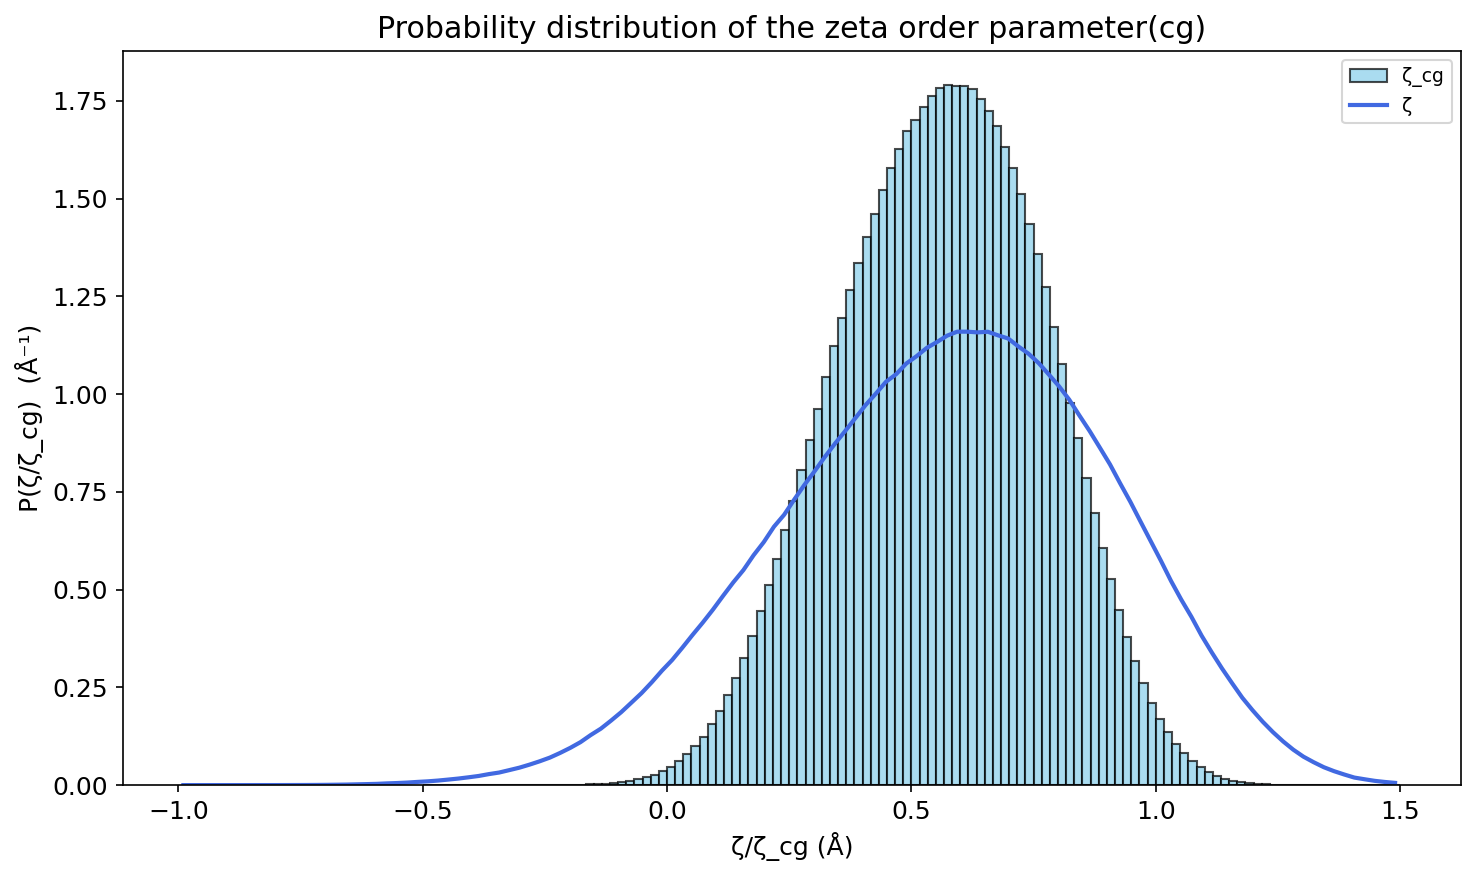

In [13]:
bin_centers, prob_density = zop.get_zeta_distribution(bins=120, range_=(-1.0, 1.5))

zeta_flat = zeta_cg_all.flatten()

fig, ax = plt.subplots(figsize=(10, 6))

bins = np.linspace(-0.5, 1.5, 121)

counts, bins, patches = ax.hist(zeta_flat, bins=bins, alpha=0.7, color='skyblue', edgecolor='black', density=True, label='ζ_cg')
ax.plot(bin_centers, prob_density, color="royalblue", lw=2.0, label='ζ')
ax.set(
    xlabel="ζ/ζ_cg (Å)",
    ylabel="P(ζ/ζ_cg)  (Å⁻¹)",
    title="Probability distribution of the zeta order parameter(cg)",
)

ax.legend(fontsize=9)
plt.tight_layout()

### Same as usual, trace one particle fluctuation

/tmp/ipykernel_73425/3248799032.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()
/tmp/ipykernel_73425/3248799032.py:28: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


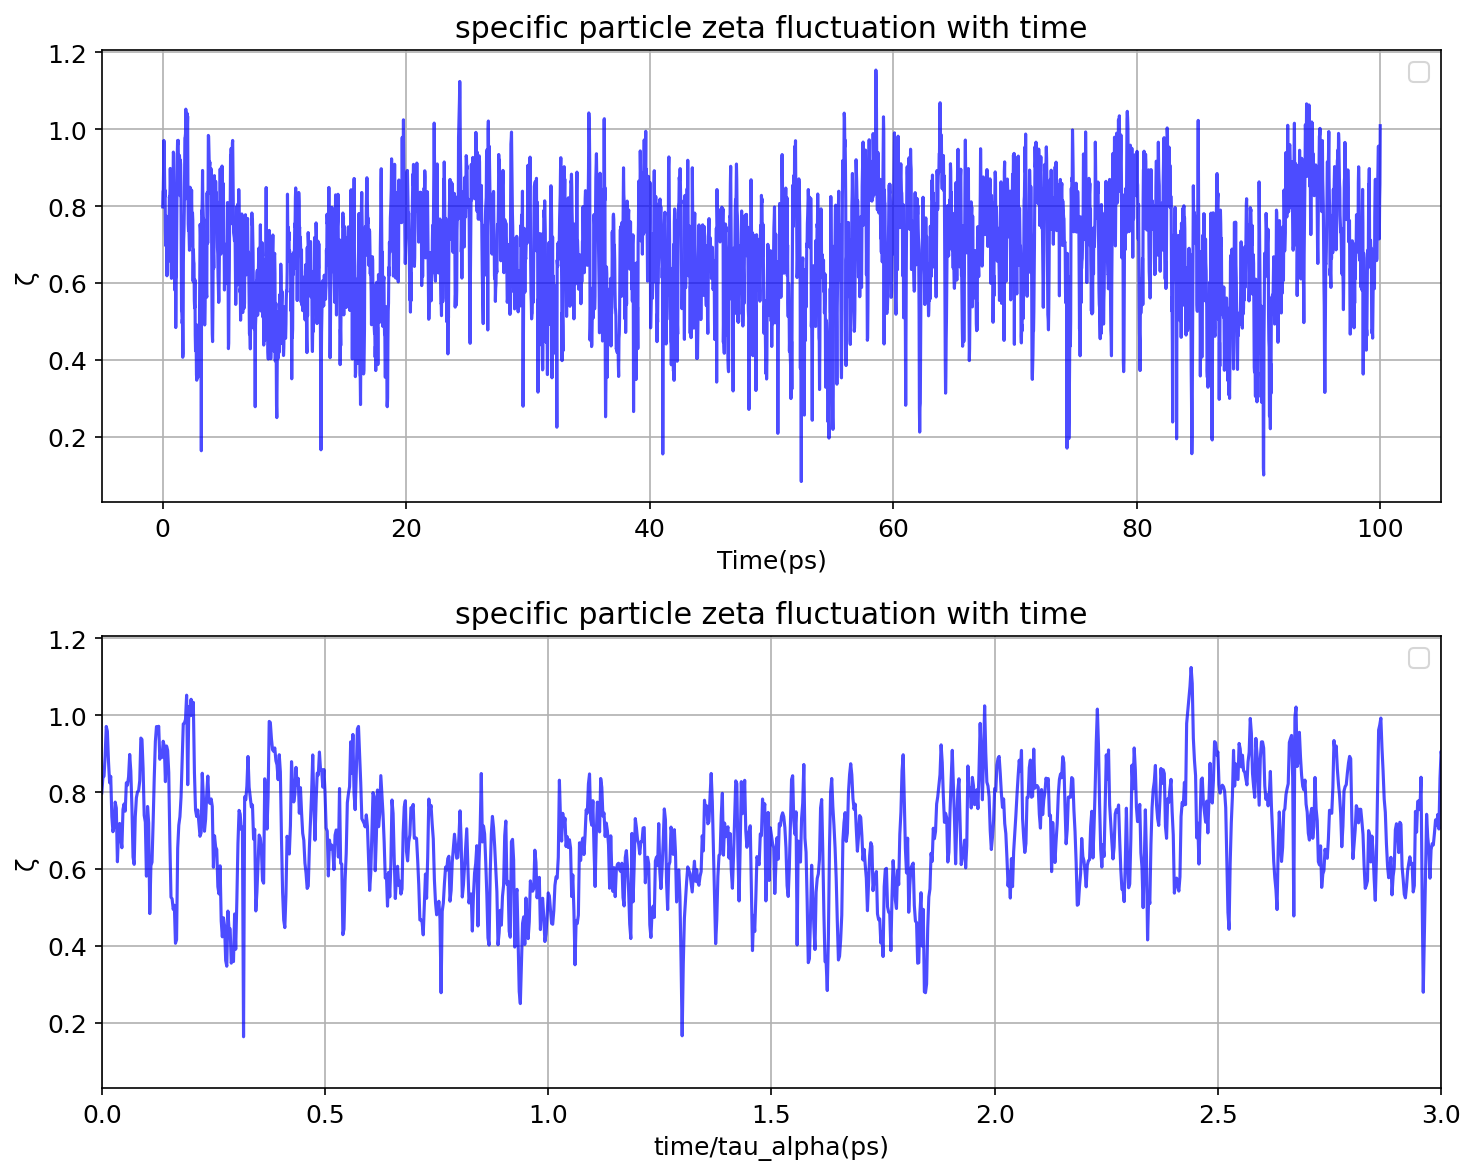

In [22]:
particle_id = 0
zeta_particle = zeta_cg_all[:, particle_id]
time_points = np.arange(len(zeta_particle)) * u.trajectory.dt

fig, axes = plt.subplots(2,1,figsize=(10, 8))
ax = axes[0]
ax.plot(time_points, zeta_particle, 'b-', linewidth=1.5, alpha=0.7)
ax.set(
    xlabel = 'Time(ps)',
    ylabel = 'ζ',
    title = 'specific particle zeta fluctuation with time'
)
ax.grid()
ax.legend()

# observe the time/time_tau 
ax = axes[1]
time_tau = 10    # ps
time_simply = time_points / time_tau
ax.plot(time_simply, zeta_particle, 'b-', linewidth=1.5, alpha=0.7)
ax.set(
    xlim = (0, 3),
    xlabel = 'time/tau_alpha(ps)',
    ylabel = 'ζ',
    title = 'specific particle zeta fluctuation with time'
)
ax.grid()
ax.legend()

plt.tight_layout()

compare it to the acceptor exchange event is important(which represents the hydrogen network arrangement locally and connects to the large-amplititude jump both rotationally and translationally)

In [23]:
switches = hba.find_hbond_switches()
"""
Returns
        -------
        list of dict
            One entry per detected switch event.  Each dict contains:

            ``"frame"``
                Frame at which the new bond was first detected.
            ``"prev_frame"``
                Preceding frame.
            ``"donor_idx"``
                Atom index of the donor (0-based).
            ``"hydrogen_idx"``
                Atom index of the hydrogen (0-based).
            ``"old_acceptor_idx"``
                Atom index of the acceptor in the previous frame.
            ``"new_acceptor_idx"``
                Atom index of the new acceptor.
            ``"jump_angle_deg"``
                Angle (in degrees) between the old D→A and new D→A unit
                vectors, computed at the frame of the switch from the stored
                trajectory positions.
"""

'\nReturns\n        -------\n        list of dict\n            One entry per detected switch event.  Each dict contains:\n\n            ``"frame"``\n                Frame at which the new bond was first detected.\n            ``"prev_frame"``\n                Preceding frame.\n            ``"donor_idx"``\n                Atom index of the donor (0-based).\n            ``"hydrogen_idx"``\n                Atom index of the hydrogen (0-based).\n            ``"old_acceptor_idx"``\n                Atom index of the acceptor in the previous frame.\n            ``"new_acceptor_idx"``\n                Atom index of the new acceptor.\n            ``"jump_angle_deg"``\n                Angle (in degrees) between the old D→A and new D→A unit\n                vectors, computed at the frame of the switch from the stored\n                trajectory positions.\n'

find different type switches event for a specific particle

In [26]:
particle_idx = int(particle_id * 3)

donor_switches = [switch for switch in switches if switch['donor_idx'] == particle_idx]
oacceptor_switches = [switch for switch in switches if switch['old_acceptor_idx'] == particle_idx]
nacceptor_switches = [switch for switch in switches if switch['new_acceptor_idx'] == particle_idx]

firstly show when they will happen compared to the zeta fluctuations

In [27]:
print(f'number of hydrogen bonds exchange events is {len(donor_switches)} for particle {particle_idx} as donor')
print(f'number of hydrogen bonds exchange events is {len(oacceptor_switches)} for particle {particle_idx} as old acceptor')
print(f'number of hydrogen bonds exchange events is {len(nacceptor_switches)} for particle {particle_idx} as new acceptor')

number of hydrogen bonds exchange events is 15 for particle 0 as donor
number of hydrogen bonds exchange events is 20 for particle 0 as old acceptor
number of hydrogen bonds exchange events is 18 for particle 0 as new acceptor


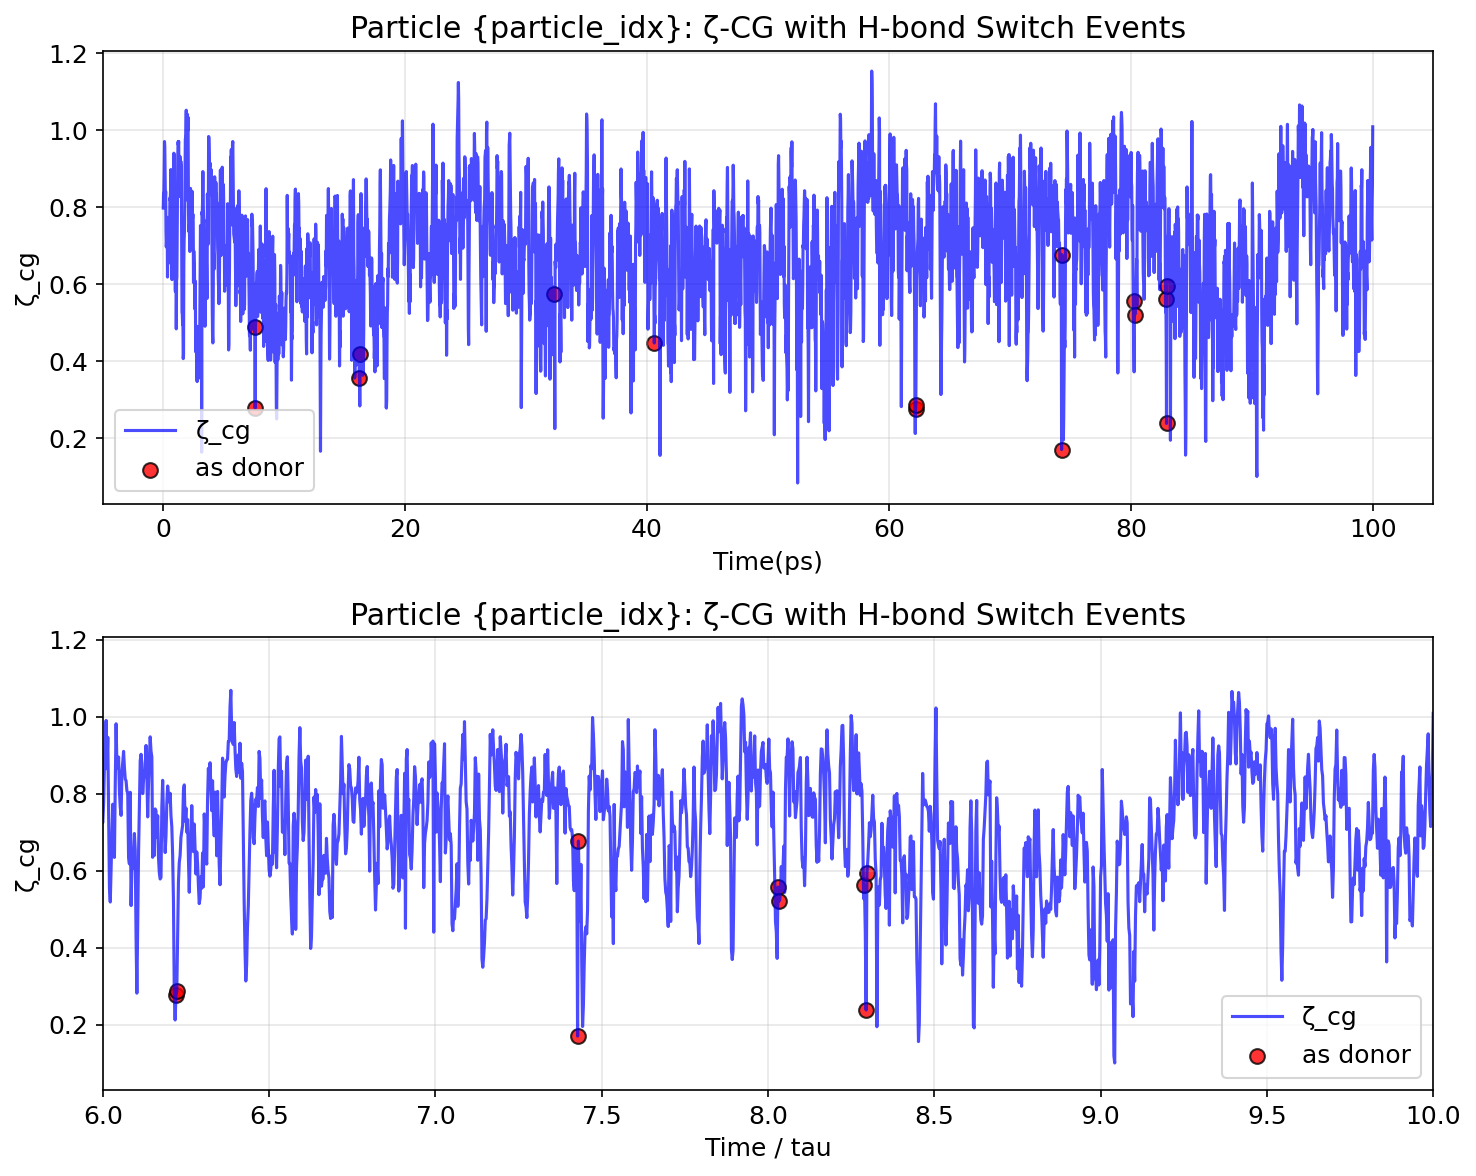

In [32]:
fig, axes = plt.subplots(2,1,figsize=(10, 8))

ax = axes[0]
ax.plot(time_points, zeta_particle, 'b-', linewidth=1.5, alpha=0.7, label='ζ_cg')
if donor_switches:
    switch_frames = [switch['frame'] for switch in donor_switches]
    # switch_angles = [switch['jump_angle_deg'] for switch in donor_switches]
    
    switch_zeta = [zeta_particle[frame] for frame in switch_frames
                    if frame < len(zeta_particle)]
    
    scatter = ax.scatter(np.array(switch_frames[:len(switch_zeta)])*u.trajectory.dt, switch_zeta, c='red', s=50, alpha=0.8, marker='o', edgecolors='black', linewidth=1, label='as donor')

# if oacceptor_switches:
#     oswitch_frames = [switch['frame'] for switch in oacceptor_switches]
#     # switch_angles = [switch['jump_angle_deg'] for switch in oacceptor_switches]
    
#     oswitch_zeta = [zeta_particle[frame] for frame in oswitch_frames
#                     if frame < len(zeta_particle)]
    
#     scatter = ax.scatter(np.array(oswitch_frames[:len(oswitch_zeta)])*u.trajectory.dt, oswitch_zeta, c='yellow', s=50, alpha=0.8, marker='o', edgecolors='black', linewidth=1, label='as old acceptor')

# if nacceptor_switches:
#     nswitch_frames = [switch['frame'] for switch in nacceptor_switches]
#     # switch_angles = [switch['jump_angle_deg'] for switch in nacceptor_switches]
    
#     nswitch_zeta = [zeta_particle[frame] for frame in nswitch_frames
#                     if frame < len(zeta_particle)]
    
#     scatter = ax.scatter(np.array(nswitch_frames[:len(nswitch_zeta)])*u.trajectory.dt, nswitch_zeta, c='grey', s=50, alpha=0.8, marker='o', edgecolors='black', linewidth=1, label='as new acceptor')    

ax.set(
    xlabel='Time(ps)',
    ylabel='ζ_cg',
    title='Particle {particle_idx}: ζ-CG with H-bond Switch Events'
)
ax.grid(True, alpha=0.3)
ax.legend()

ax = axes[1]
ax.plot(time_simply, zeta_particle, 'b-', linewidth=1.5, alpha=0.7, label='ζ_cg')

if donor_switches:
    scatter = ax.scatter(np.array(switch_frames[:len(switch_zeta)])* u.trajectory.dt / time_tau, switch_zeta, c='red', s=50, alpha=0.8, marker='o', edgecolors='black', linewidth=1, label='as donor')
# if oacceptor_switches:
#     scatter = ax.scatter(np.array(oswitch_frames[:len(oswitch_zeta)])* u.trajectory.dt / time_tau, oswitch_zeta, c='yellow', s=50, alpha=0.8, marker='o', edgecolors='black', linewidth=1, label='as old acceptor')
# if nacceptor_switches:
#     scatter = ax.scatter(np.array(nswitch_frames[:len(nswitch_zeta)])* u.trajectory.dt / time_tau, nswitch_zeta, c='grey', s=50, alpha=0.8, marker='o', edgecolors='black', linewidth=1, label='as new acceptor')
ax.set(
    xlim = (6, 10),
    xlabel='Time / tau',
    ylabel='ζ_cg',
    title='Particle {particle_idx}: ζ-CG with H-bond Switch Events'
)
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()

考虑能否将一次发生一次受体交换重排前的结果进行粗粒化平均处理，相当于歼灭了热效应噪声的影响。因为认为一次受体交换重排前的局部状态趋于稳定。但同时，这一假设中我们并不保证说一次受体交换重排就会导致其发生LDL-HDL迁移。我们只说它由于改变了粒子的局域氢键网络状态，因而理论上会使得序参量发生某种程度上irreversible的改变。所以我们以此为划分，对粒子在这一段运动时间内的序参量进行平均处理。。

**可能需要观测一下每次发生irreversible重排的相隔时间之间的分布特征，或许对我们的统计有帮助**

### 平衡态模拟结果分析：225K 1bar 0.2ps dump一次，共1001帧（200ps）

In [1]:
import argparse
from collections import defaultdict
from pathlib import Path
from typing import Dict, Iterable, Optional

import MDAnalysis as mda
from MDAnalysis.lib.nsgrid import FastNS
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm import tqdm

In [3]:
# 检查氢键数量
hb_counts = pd.read_csv("/home/debian/water/TIP4P/2005/rstforhoofixed/hb_counts_per_idx.csv")
print(hb_counts.head())
zeta_valid = pd.read_csv("/home/debian/water/TIP4P/2005/rstforhoofixed/zeta_valid.csv")
print(zeta_valid.head())

   frame  O_idx  O_id  hb_count
0      0      0     1         3
1      0      3     4         4
2      0      6     7         4
3      0      9    10         4
4      0     12    13         4
   frame  O_idx  O_id  hb_count  max_hb_distance  min_nonhb_distance      zeta
0      0      0     1         3         2.806473            3.235965  0.429492
1      0      3     4         4         3.113102            3.390775  0.277672
2      0      6     7         4         3.032763            3.623430  0.590667
3      0      9    10         4         3.108895            3.583482  0.474587
4      0     12    13         4         2.951813            3.341237  0.389423


Text(0.95, 0.95, 'Average: 3.93')

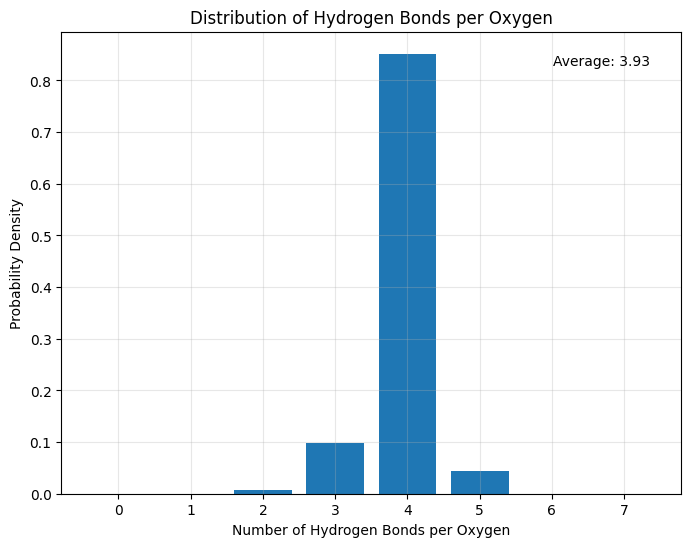

In [6]:
# 检查氢键数量：
plt.figure(figsize=(8,6))
plt.hist(
            hb_counts['hb_count'], bins=range(0, max(hb_counts['hb_count']) + 2), density=True, align="left", rwidth=0.8
        )
plt.xlabel("Number of Hydrogen Bonds per Oxygen")
plt.ylabel("Probability Density")
plt.title("Distribution of Hydrogen Bonds per Oxygen")
plt.grid(alpha=0.3)
plt.text(
            0.95,
            0.95,
            f"Average: {np.mean(hb_counts['hb_count']):.2f}",
            transform=plt.gca().transAxes,
            ha="right",
            va="top",
        )

In [8]:
# ζ分布分解尝试
from scipy.optimize import curve_fit
from scipy.stats import norm

from scipy.stats import gaussian_kde
from scipy.stats import iqr
from scipy.signal import savgol_filter
def data_smooth(zeta):
        data = zeta["zeta"].values
        n = len(data)
                # 使用Silverman法则计算最优带宽
        silverman_bandwidth = 0.9 * min(np.std(data), iqr(data) / 1.34) * n ** (-0.2)
        print(f"Silverman带宽: {silverman_bandwidth:.6f}")
                # 使用高斯核密度估计
        kde = gaussian_kde(data, bw_method=silverman_bandwidth)
        window_length = 51 if n >= 51 else (n // 2) * 2 + 1  # 确保窗口长度为奇数且不超过数据点数
        polyorder = 3 if window_length > 3 else 2  # 多项式阶数小于窗口长度
        plt.figure(figsize=(10, 6))
        x = np.linspace(data.min(), data.max(), 1000)
        smoothed_kde = savgol_filter(kde(x), window_length=window_length, polyorder=polyorder)
                # plt.plot(x, kde(x), "-k", lw=2, label="KDE Estimate")
        plt.plot(x, smoothed_kde, "--b", lw=2, label="Smoothed KDE")
        hist, bin_edges, _ = plt.hist(
                data, bins=300, density=True, alpha=0.3, color="gray", label="Data Histogram"
                )
        plt.axvline(x=0, color="red", linestyle="--", label="ζ=0")
        plt.xlabel("Zeta Distance (nm)")
        plt.ylabel("Probability Density")
        plt.title("Kernel Density Estimation of Zeta Distance")
        plt.legend()
        return smoothed_kde, x
def P_rho(p, zeta):
    return np.exp(-(zeta - p[0])**2/(2 * p[1]**2)) / (p[1] * np.sqrt(2*np.pi))
def mixture_model(zeta, mu1, sigma1, mu2, sigma2, s):
    p1 = [mu1, sigma1]
    p2 = [mu2, sigma2]
    return (1 - s) * P_rho(p1, zeta) + s * P_rho(p2, zeta)
from scipy.optimize import minimize
from scipy.integrate import quad

def objective_function(params, zeta_values, kde_values, zeta_zero_density):
    """目标函数：同时拟合整体分布和ζ=0处的约束"""
    mu1, sigma1, mu2, sigma2, s = params
    
    # 约束1：整体分布拟合误差
    predicted_kde = mixture_model(zeta_values, mu1, sigma1, mu2, sigma2, s)
    fit_error = np.sum((predicted_kde - kde_values)**2)
    
    # 约束2：ζ=0处的密度约束
    density_at_zero = mixture_model(0, mu1, sigma1, mu2, sigma2, s)
    zero_constraint_error = (density_at_zero - zeta_zero_density)**2 * 1000  # 加权
    
    # 约束3：物理合理性约束（可选）
    # 确保sigma为正，s在[0,1]之间
    penalty = 0
    if sigma1 <= 0 or sigma2 <= 0 or s < 0 or s > 1:
        penalty += 1000
    
    return fit_error + zero_constraint_error + penalty

def solve_mixture_model(x, y, zeta_zero_density):
    """解决混合模型参数估计问题"""
    
    # 方法1：基于物理理解的初始猜测
    # 观察您的KDE图形，猜测两个高斯分量的位置
    # 例如：一个在0附近，一个在某个特征位置
    
    # 手动调节寻找峰值作为参考
    peak1_pos = x[np.argmax(y)]
    peak2_pos = 0
    
    
    # 初始参数猜测 [mu1, sigma1, mu2, sigma2, s]
    initial_guess = [peak2_pos, 1.0, peak1_pos, 1.0, 0.3]
    
    # 参数边界
    bounds = [
        (x.min(), x.max()),  # mu1范围
        (0.1, 10),           # sigma1范围
        (x.min(), x.max()),  # mu2范围
        (0.1, 10),           # sigma2范围
        (0, 1)               # s在[0,1]之间
    ]
    
    # 优化
    result = minimize(
        objective_function,
        initial_guess,
        args=(x, y, zeta_zero_density),
        bounds=bounds,
        method='L-BFGS-B',
        options={"maxiter":1000}
    )
    
    if result.success:
        mu1_opt, sigma1_opt, mu2_opt, sigma2_opt, s_opt = result.x
        
        # 验证结果
        predicted_at_zero = mixture_model(0, mu1_opt, sigma1_opt, mu2_opt, sigma2_opt, s_opt)
        fit_quality = np.sqrt(np.mean((mixture_model(x, mu1_opt, sigma1_opt, mu2_opt, sigma2_opt, s_opt) - y)**2))
        
        print("=== 参数估计结果 ===")
        print(f"第一个高斯分量: μ1 = {mu1_opt:.4f}, σ1 = {sigma1_opt:.4f}")
        print(f"第二个高斯分量: μ2 = {mu2_opt: .4f}, σ2 = {sigma2_opt:.4f}")
        print(f"混合系数 s = {s_opt:.4f} (第二个分量的权重)")
        print(f"约束验证: P(ζ=0) = {predicted_at_zero:.6f} (目标: {zeta_zero_density:.6f})")
        print(f"拟合均方根误差: {fit_quality:.6f}")
        
        return result.x
    else:
        print("优化失败:", result.message)
        return None

# 使用示例
# estimated_params = solve_mixture_model(x, y, zeta_zero_density)

# 可视化结果
def plot_results(x, y, params, zeta_zero_density):
    """绘制拟合结果"""
    mu1, sigma1, mu2,sigma2, s = params
    
    plt.figure(figsize=(12, 8))
    
    # 原始数据
    plt.plot(x, y, 'k-', lw=2, label='original KDE', alpha=0.7)
    
    # 拟合结果
    y_fit = mixture_model(x, mu1, sigma1, mu2, sigma2, s)
    plt.plot(x, y_fit, 'r--', lw=2, label='double gaussian mixture')
    
    # 各个分量
    y1 = (1 - s) * P_rho([mu1, sigma1], x)
    y2 = s * P_rho([mu2, sigma2], x)
    plt.plot(x, y1, 'b:', lw=1, label=f'Component 1 (Weight: {1-s:.3f})')
    plt.plot(x, y2, 'g:', lw=1, label=f'Component 2 (Weight: {s:.3f})')
    
    # ζ=0处的约束点
    plt.axvline(x=0, color='red', linestyle='--', alpha=0.5, label='ζ=0')
    plt.scatter(0, zeta_zero_density, color='red', s=100, zorder=5, 
                label=f'Striction point: P(0)={zeta_zero_density:.4f}')
    
    plt.xlabel('Zeta Distance)')
    plt.ylabel('Probability Density')
    plt.title('Result for double gaussian model')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# 调用绘图
# if estimated_params is not None:
#     plot_results(x, y, estimated_params, zeta_zero_density)

Silverman带宽: 0.014672
ζ=0处的真实概率密度值: 0.283593
=== 参数估计结果 ===
第一个高斯分量: μ1 = 0.3907, σ1 = 1.0511
第二个高斯分量: μ2 =  0.6176, σ2 = 0.3681
混合系数 s = 1.0000 (第二个分量的权重)
约束验证: P(ζ=0) = 0.265259 (目标: 0.283593)
拟合均方根误差: 0.053744


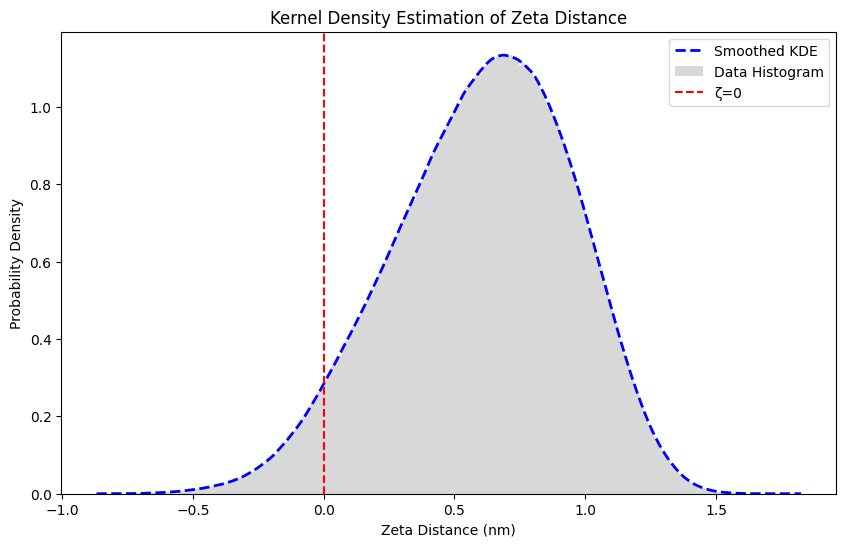

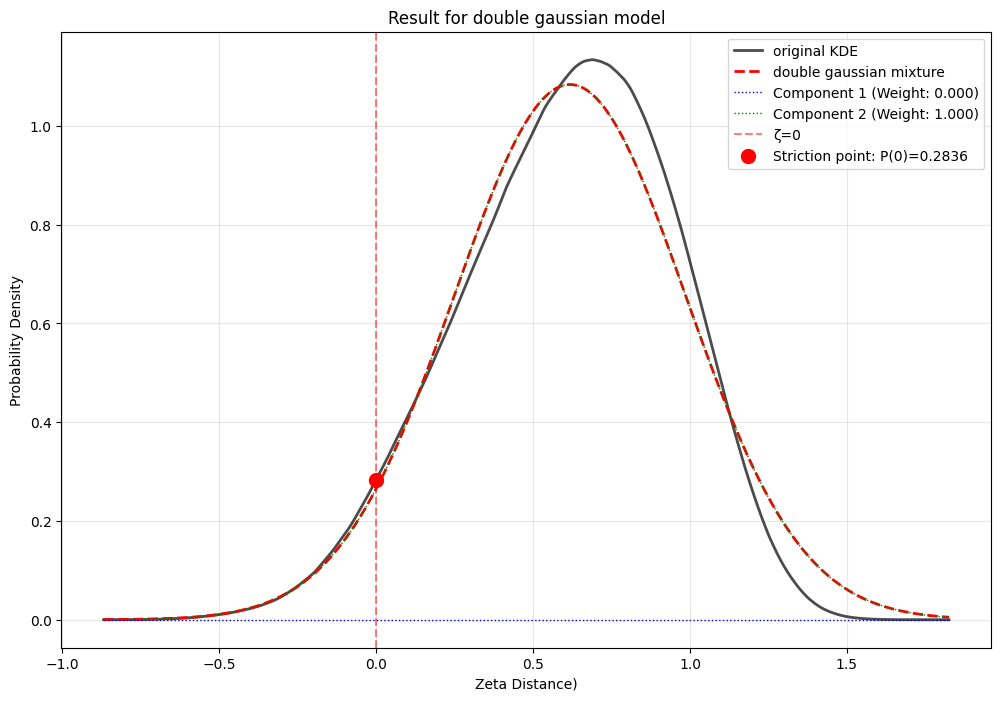

In [10]:
smoothed_kde, x = data_smooth(zeta_valid)
zeta_zero_density = smoothed_kde[np.argmin(np.abs(x-0))]
print(f"ζ=0处的真实概率密度值: {zeta_zero_density:.6f}")
estimated_params = solve_mixture_model(x, smoothed_kde, zeta_zero_density)
plot_results(x, smoothed_kde, estimated_params, zeta_zero_density)

结论：分割失败，但是我们可以先不用管这一点。就继续进行分析即可。for example 观察每个粒子的ζ形态维稳程度进行分析

分析流程：

1. **氢键判据对照**
   由 `hb_dynamics_postprocess.py` 完成。
   它会输出：

   * `hb_count_distribution.csv/png`
   * `hb_count_frame_summary.csv`
   * `hb_criterion_comparison_summary.csv`（如果你提供旧版 `hb_counts.csv`）

2. **单键连续/间歇寿命**
   由 `hb_dynamics_postprocess.py` 完成。
   它会输出：

   * `hb_lifetime_correlations.csv/png`
   * `hb_continuous_run_lengths.csv`

3. **单分子氢键数时间序列与自相关**
   由 `hb_dynamics_postprocess.py` 完成。
   它会输出：

   * `hb_count_autocorr.csv/png`
   * `hb_count_per_molecule_fluctuation.csv`

4. **partner retention / partner exchange 时间**
   由 `hb_dynamics_postprocess.py` 完成。
   它会输出：

   * `partner_retention_curve.csv/png`
   * `partner_first_change_times.csv`
   * `partner_full_renewal_times.csv`

5. **(\zeta_i(t))、(\zeta_{cg,i}(t)) 分布与自相关**
   由 `zeta_dynamics_postprocess.py` 完成。
   它会输出：

   * `zeta_distribution.csv/png`
   * `zeta_frame_stats.csv`
   * `zeta_autocorr.csv/png`
   * `zeta_cg_distribution.csv/png`
   * `zeta_cg_frame_stats.csv`
   * `zeta_cg_autocorr.csv/png`

另外，`hb_extract_hoo_timeseries.py` 是整套前处理入口，用 **HOO 判据** 从 dump 里抽出逐帧氢键网络，生成：

* `hb_edges.csv`
* `hb_counts.csv`
* `hb_frame_summary.csv`
* `hb_meta.json`

`run_first5_pipeline.py` 则把前 1–5 项串起来自动跑。

---

### 用法

用新的 `zeta.csv` 或 `zeta_valid.csv`：

```bash
python run_first5_pipeline.py \
  --dump_file traj.lammpstrj \
  --work_dir analysis_out \
  --zeta_csv zeta_valid.csv
```

和旧判据对比：

```bash
python run_first5_pipeline.py \
  --dump_file traj.lammpstrj \
  --work_dir analysis_out \
  --zeta_csv zeta_valid.csv \
  --old_counts_csv old_hb_counts.csv
```

提前算好了 `zeta_cg.csv`：

```bash
python run_first5_pipeline.py \
  --dump_file traj.lammpstrj \
  --work_dir analysis_out \
  --zeta_csv zeta_valid.csv \
  --zeta_cg_csv zeta_cg.csv
```

---

### 这套流程内部的逻辑

* 氢键网络统一按你现在的 **HOO 判据**：

  * `O···O <= oo_cutoff`
  * `min(H-O···O) <= hoo_cutoff`
* 水分子 O→H 映射会自动尝试：

  * residue
  * 顺序 O-H-H
  * 几何最近邻
* 前四项全部基于同一份 `hb_edges.csv / hb_counts.csv`，避免不同脚本标准不一致
* 第五项直接读取你新的 `zeta.csv / zeta_valid.csv` 和 `zeta_cg.csv`

---

### 坑

* 连续寿命和间歇相关函数分开输出，不混在一起
* partner exchange 同时给了两种时间：

  * `first_change_time`
  * `full_renewal_time`
* `zeta_dynamics_postprocess.py` 会自动过滤 `status != ok` 的行
* `run_first5_pipeline.py` 在你没提供 `zeta_cg.csv` 时，会自动调用你现有的 `zeta_cg_hoo_updated.py`

---


In [2]:
hb_count_corr = pd.read_csv("/home/debian/water/TIP4P/2005/rstforhoofixed/analysis_out/hb_post_fixed/hb_count_autocorr.csv")
hb_lifetime_corr = pd.read_csv("/home/debian/water/TIP4P/2005/rstforhoofixed/analysis_out/hb_post_fixed/hb_lifetime_correlations.csv")
partner_retention_curve = pd.read_csv("/home/debian/water/TIP4P/2005/rstforhoofixed/analysis_out/hb_post_fixed/partner_retention_curve.csv")

In [3]:
timestep = 0.2

线性插值得到的 τ = 0.328 ps
指数拟合得到的 τ = 5.324 ps


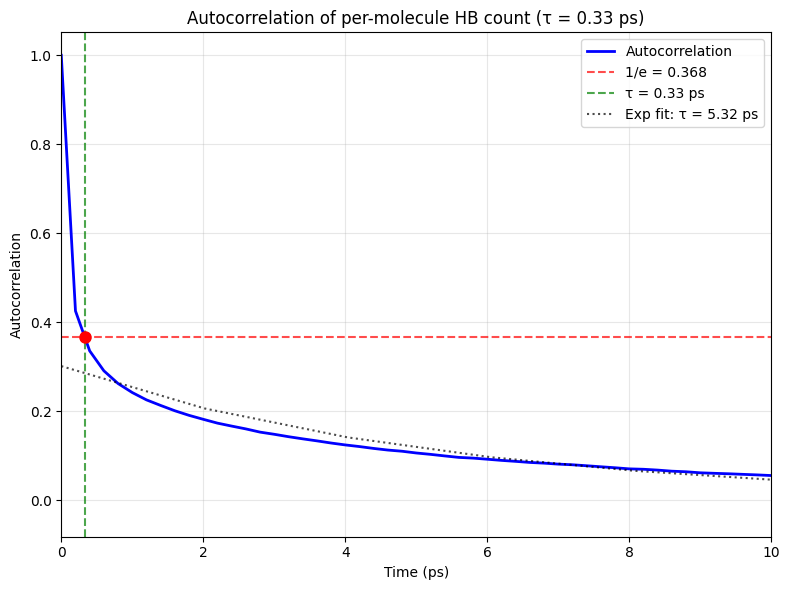

氢键数量自相关函数特征时间:
  1/e 衰减时间 τ = 0.328 ps
  对应的自相关延迟帧数 = 1.6 frames
  初始自相关值 ACF(0) = 1.0000
  最终自相关值 ACF(200.0 ps) = 0.0005


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 计算时间轴
time = hb_count_corr['lag'] * timestep
acf = hb_count_corr['mean_autocorr']

# 1. 计算特征时间 τ
target_value = 1 / np.exp(1)  # 1/e

# 找到第一次低于目标值的点
below_target = acf < target_value
if below_target.any():
    first_below_idx = np.where(below_target)[0][0]
    
    if first_below_idx > 0:
        # 线性插值
        t1 = time.iloc[first_below_idx - 1]
        t2 = time.iloc[first_below_idx]
        a1 = acf.iloc[first_below_idx - 1]
        a2 = acf.iloc[first_below_idx]
        
        tau = t1 + (target_value - a1) * (t2 - t1) / (a2 - a1)
    else:
        tau = time.iloc[0]
else:
    # 如果没有点低于1/e，取最后一点
    tau = time.iloc[-1]

# 2. 绘制自相关函数并标注τ
plt.figure(figsize=(8, 6))
plt.plot(time, acf, 'b-', linewidth=2, label='Autocorrelation')

# 添加1/e水平线和τ垂直线
plt.axhline(y=target_value, color='r', linestyle='--', alpha=0.7, label='1/e = {:.3f}'.format(target_value))
plt.axvline(x=tau, color='g', linestyle='--', alpha=0.7, label=f'τ = {tau:.2f} ps')

# 标记τ点
plt.plot(tau, target_value, 'ro', markersize=8)

plt.xlabel("Time (ps)")
plt.xlim(left=0, right=10)  # 根据您的设置
plt.ylabel('Autocorrelation')
plt.title(f"Autocorrelation of per-molecule HB count (τ = {tau:.2f} ps)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

# 3. 可选：指数拟合以验证τ
# 如果自相关函数呈指数衰减，可以进行拟合
if len(time) > 1 and acf.iloc[0] > 0:
    # 对衰减部分进行指数拟合（从第二个点开始，避免acf[0]=1的奇点）
    mask = (time > 0) & (acf > 0)
    if mask.sum() > 2:
        from scipy.optimize import curve_fit
        
        def exp_decay(t, A, tau_fit):
            return A * np.exp(-t / tau_fit)
        
        try:
            popt, pcov = curve_fit(exp_decay, time[mask], acf[mask], 
                                  p0=[1.0, tau])
            tau_fit = popt[1]
            
            # 绘制拟合曲线
            t_fine = np.linspace(0, time.iloc[-1], 100)
            plt.plot(t_fine, exp_decay(t_fine, *popt), 'k:', 
                    label=f'Exp fit: τ = {tau_fit:.2f} ps', alpha=0.7)
            plt.legend()
            
            print(f"线性插值得到的 τ = {tau:.3f} ps")
            print(f"指数拟合得到的 τ = {tau_fit:.3f} ps")
        except:
            print("指数拟合失败，使用线性插值结果")

plt.show()

# 输出结果
print("=" * 50)
print(f"氢键数量自相关函数特征时间:")
print(f"  1/e 衰减时间 τ = {tau:.3f} ps")
print(f"  对应的自相关延迟帧数 = {tau/timestep:.1f} frames")
print(f"  初始自相关值 ACF(0) = {acf.iloc[0]:.4f}")
print(f"  最终自相关值 ACF({time.iloc[-1]:.1f} ps) = {acf.iloc[-1]:.4f}")

线性插值得到的 τ = 20.842 ps
指数拟合得到的 τ = 28.380 ps


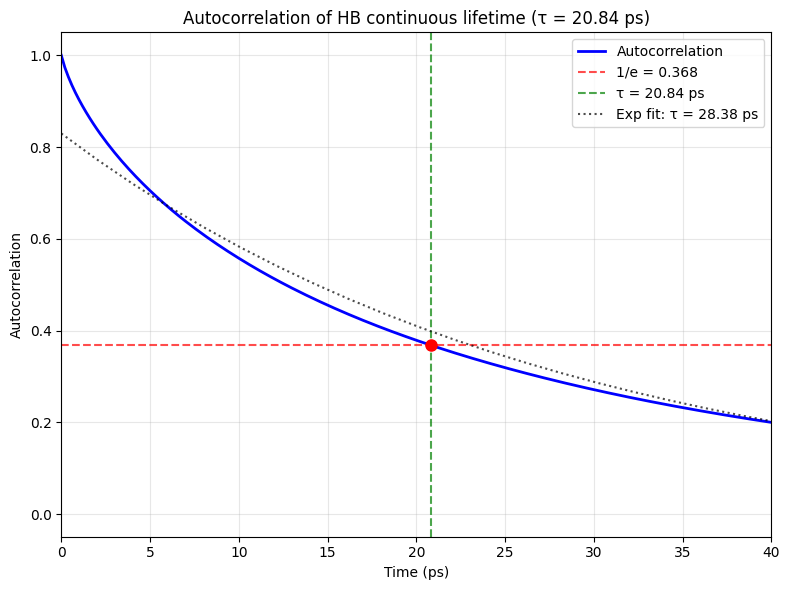

氢键数量自相关函数特征时间:
  1/e 衰减时间 τ = 20.842 ps
  对应的自相关延迟帧数 = 104.2 frames
  初始自相关值 ACF(0) = 1.0000
  最终自相关值 ACF(200.0 ps) = 0.0055


In [10]:
# 计算时间轴
time = hb_lifetime_corr['lag'] * timestep
acf = hb_lifetime_corr['continuous_survival_exact']

# 1. 计算特征时间 τ
target_value = 1 / np.exp(1)  # 1/e

# 找到第一次低于目标值的点
below_target = acf < target_value
if below_target.any():
    first_below_idx = np.where(below_target)[0][0]
    
    if first_below_idx > 0:
        # 线性插值
        t1 = time.iloc[first_below_idx - 1]
        t2 = time.iloc[first_below_idx]
        a1 = acf.iloc[first_below_idx - 1]
        a2 = acf.iloc[first_below_idx]
        
        tau = t1 + (target_value - a1) * (t2 - t1) / (a2 - a1)
    else:
        tau = time.iloc[0]
else:
    # 如果没有点低于1/e，取最后一点
    tau = time.iloc[-1]

# 2. 绘制自相关函数并标注τ
plt.figure(figsize=(8, 6))
plt.plot(time, acf, 'b-', linewidth=2, label='Autocorrelation')

# 添加1/e水平线和τ垂直线
plt.axhline(y=target_value, color='r', linestyle='--', alpha=0.7, label='1/e = {:.3f}'.format(target_value))
plt.axvline(x=tau, color='g', linestyle='--', alpha=0.7, label=f'τ = {tau:.2f} ps')

# 标记τ点
plt.plot(tau, target_value, 'ro', markersize=8)

plt.xlabel("Time (ps)")
plt.xlim(left=0, right=40)  # 根据您的设置
plt.ylabel('Autocorrelation')
plt.title(f"Autocorrelation of HB continuous lifetime (τ = {tau:.2f} ps)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

# 3. 可选：指数拟合以验证τ
# 如果自相关函数呈指数衰减，可以进行拟合
if len(time) > 1 and acf.iloc[0] > 0:
    # 对衰减部分进行指数拟合（从第二个点开始，避免acf[0]=1的奇点）
    mask = (time > 0) & (acf > 0)
    if mask.sum() > 2:
        from scipy.optimize import curve_fit
        
        def exp_decay(t, A, tau_fit):
            return A * np.exp(-t / tau_fit)
        
        try:
            popt, pcov = curve_fit(exp_decay, time[mask], acf[mask], 
                                  p0=[1.0, tau])
            tau_fit = popt[1]
            
            # 绘制拟合曲线
            t_fine = np.linspace(0, time.iloc[-1], 100)
            plt.plot(t_fine, exp_decay(t_fine, *popt), 'k:', 
                    label=f'Exp fit: τ = {tau_fit:.2f} ps', alpha=0.7)
            plt.legend()
            
            print(f"线性插值得到的 τ = {tau:.3f} ps")
            print(f"指数拟合得到的 τ = {tau_fit:.3f} ps")
        except:
            print("指数拟合失败，使用线性插值结果")

plt.show()

# 输出结果
print("=" * 50)
print(f"氢键数量自相关函数特征时间:")
print(f"  1/e 衰减时间 τ = {tau:.3f} ps")
print(f"  对应的自相关延迟帧数 = {tau/timestep:.1f} frames")
print(f"  初始自相关值 ACF(0) = {acf.iloc[0]:.4f}")
print(f"  最终自相关值 ACF({time.iloc[-1]:.1f} ps) = {acf.iloc[-1]:.4f}")

线性插值得到的 τ = 200.000 ps
指数拟合得到的 τ = 252.780 ps


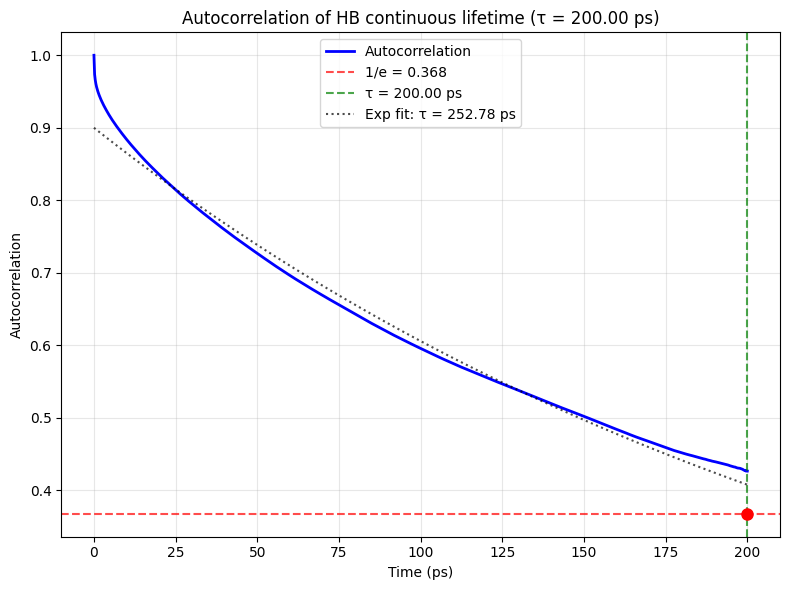

氢键数量自相关函数特征时间:
  1/e 衰减时间 τ = 200.000 ps
  对应的自相关延迟帧数 = 1000.0 frames
  初始自相关值 ACF(0) = 1.0000
  最终自相关值 ACF(200.0 ps) = 0.4268


In [12]:
# 计算时间轴
time = partner_retention_curve['lag'] * timestep
acf = partner_retention_curve['partner_retention']

# 1. 计算特征时间 τ
target_value = 1 / np.exp(1)  # 1/e

# 找到第一次低于目标值的点
below_target = acf < target_value
if below_target.any():
    first_below_idx = np.where(below_target)[0][0]
    
    if first_below_idx > 0:
        # 线性插值
        t1 = time.iloc[first_below_idx - 1]
        t2 = time.iloc[first_below_idx]
        a1 = acf.iloc[first_below_idx - 1]
        a2 = acf.iloc[first_below_idx]
        
        tau = t1 + (target_value - a1) * (t2 - t1) / (a2 - a1)
    else:
        tau = time.iloc[0]
else:
    # 如果没有点低于1/e，取最后一点
    tau = time.iloc[-1]

# 2. 绘制自相关函数并标注τ
plt.figure(figsize=(8, 6))
plt.plot(time, acf, 'b-', linewidth=2, label='Autocorrelation')

# 添加1/e水平线和τ垂直线
plt.axhline(y=target_value, color='r', linestyle='--', alpha=0.7, label='1/e = {:.3f}'.format(target_value))
plt.axvline(x=tau, color='g', linestyle='--', alpha=0.7, label=f'τ = {tau:.2f} ps')

# 标记τ点
plt.plot(tau, target_value, 'ro', markersize=8)

plt.xlabel("Time (ps)")
# plt.xlim(left=0, right=40)  # 根据您的设置
plt.ylabel('Autocorrelation')
plt.title(f"Autocorrelation of HB continuous lifetime (τ = {tau:.2f} ps)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

# 3. 可选：指数拟合以验证τ
# 如果自相关函数呈指数衰减，可以进行拟合
if len(time) > 1 and acf.iloc[0] > 0:
    # 对衰减部分进行指数拟合（从第二个点开始，避免acf[0]=1的奇点）
    mask = (time > 0) & (acf > 0)
    if mask.sum() > 2:
        from scipy.optimize import curve_fit
        
        def exp_decay(t, A, tau_fit):
            return A * np.exp(-t / tau_fit)
        
        try:
            popt, pcov = curve_fit(exp_decay, time[mask], acf[mask], 
                                  p0=[1.0, tau])
            tau_fit = popt[1]
            
            # 绘制拟合曲线
            t_fine = np.linspace(0, time.iloc[-1], 100)
            plt.plot(t_fine, exp_decay(t_fine, *popt), 'k:', 
                    label=f'Exp fit: τ = {tau_fit:.2f} ps', alpha=0.7)
            plt.legend()
            
            print(f"线性插值得到的 τ = {tau:.3f} ps")
            print(f"指数拟合得到的 τ = {tau_fit:.3f} ps")
        except:
            print("指数拟合失败，使用线性插值结果")

plt.show()

# 输出结果
print("=" * 50)
print(f"氢键数量自相关函数特征时间:")
print(f"  1/e 衰减时间 τ = {tau:.3f} ps")
print(f"  对应的自相关延迟帧数 = {tau/timestep:.1f} frames")
print(f"  初始自相关值 ACF(0) = {acf.iloc[0]:.4f}")
print(f"  最终自相关值 ACF({time.iloc[-1]:.1f} ps) = {acf.iloc[-1]:.4f}")